In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.misc import derivative

# Функция распределения F(x)
def F(x):
    return np.where(x >= 0, 1 - np.exp(-x**2 / 2), 0.0)

# Интеграл G(x) = C * ∫_{x-1}^{x+1} F(t) * arctg(|x - t|) dt
# C выберем позже так, чтобы g(x) интегрировалась до 1
def G(x):
    integrand = lambda t: F(t) * np.arctan(np.abs(x - t))
    result, _ = quad(integrand, x - 1, x + 1)
    return result

# Производная G(x) численно — это плотность g(x)
def g(x):
    return derivative(G, x, dx=1e-6)

# Вычислим g(x) на отрезке [0, 5]
x_vals = np.linspace(0, 5, 500)
g_vals_unnorm = np.array([g(x) for x in x_vals])

# Нормировка: найдём C такое, что ∫ g(x) dx = 1
area, _ = quad(lambda x: derivative(G, x, dx=1e-6), 0, 5)
C = 1 / area
g_vals = g_vals_unnorm * C

# Нормализованная плотность g(x)
def g_norm(x):
    return derivative(G, x, dx=1e-6) * C

# Вычисляем матожидание и дисперсию
mean, _ = quad(lambda x: x * g_norm(x), 0, 5)
second_moment, _ = quad(lambda x: x**2 * g_norm(x), 0, 5)
variance = second_moment - mean**2

variance


/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_35605/3488735960.py:19: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  return derivative(G, x, dx=1e-6)
/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_35605/3488735960.py:26: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  area, _ = quad(lambda x: derivative(G, x, dx=1e-6), 0, 5)
/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_35605/3488735960.py:26: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  

0.7086186508282442

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.misc import derivative
import sympy as sp

# 1. Определяем F(x)
def F(x):
    return np.where(x >= 0, 1 - np.exp(-x**2 / 2), 0)

# 2. Находим нормировочную константу C
def integrand_for_C(t, x_large=1e6):
    # При больших x F(t) ≈ 1 в пределах [x-1, x+1]
    return np.arctan(np.abs(x_large - t))

C_integral, _ = quad(integrand_for_C, -1, 1)  # Замена u = t - x → du = dt
C = 1 / C_integral

print(f"Нормировочная константа C = {C}")

# 3. Определяем G(x) через численное интегрирование
def G(x):
    def integrand(t):
        return F(t) * np.arctan(np.abs(x - t))
    
    lower = x - 1
    upper = x + 1
    integral, _ = quad(integrand, lower, upper)
    return C * integral

# 4. Находим плотность g(x) = G'(x) (численно через конечные разности)
def g(x, h=1e-5):
    return derivative(G, x, dx=h)

# 5. Вычисляем E[X] и E[X²] (интегралы от -∞ до ∞)
def expectation(k, lower=-10, upper=10):
    # k=1 → E[X], k=2 → E[X²] (верхний предел 10, т.к. F(x) быстро убывает)
    def integrand(x):
        return x**k * g(x)
    
    integral, _ = quad(integrand, lower, upper)
    return integral

E_X = expectation(1)
E_X_squared = expectation(2)
variance = E_X_squared - E_X**2

print(f"Матожидание E[X] ≈ {E_X}")
print(f"E[X²] ≈ {E_X_squared}")
print(f"Дисперсия Var(X) ≈ {variance}")

# Проверка, что G(x) нормирована (G(∞) ≈ 1)
print(f"G(10) ≈ {G(10)} (должно быть ≈ 1)")

Нормировочная константа C = 0.318310088826287


/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_35605/1182000013.py:32: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  return derivative(G, x, dx=h)
/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_35605/1182000013.py:27: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, _ = quad(integrand, lower, upper)
/var/folders/7k/q1n29k35429d2mnrn_3mbtjr0000gn/T/ipykernel_35605/1182000013.py:40: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the inter

Матожидание E[X] ≈ 0.3501315868994536
E[X²] ≈ 0.6928378062402707
Дисперсия Var(X) ≈ 0.570245678095541
G(10) ≈ 0.27936457769636225 (должно быть ≈ 1)


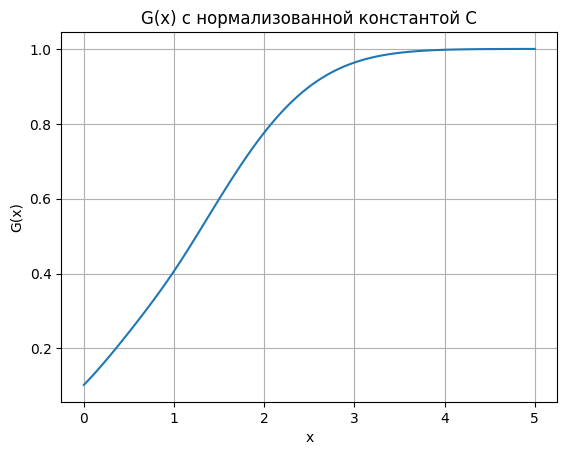

G(1) = 0.4065604883


In [4]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt

# Функция распределения F(x)
def F(t):
    return 1 - np.exp(-t**2 / 2) if t >= 0 else 0

# Интегральная функция
def integrand(t, x):
    return F(t) * np.arctan(np.abs(x - t))

# Функция G(x) с учетом константы C
def G(x, C=1.0):
    result, _ = integrate.quad(lambda t: integrand(t, x), x - 1, x + 1)
    return C * result

# Тестовые значения x
x_values = np.linspace(0, 5, 100)
G_values = [G(x) for x in x_values]

# Нормализация: подбираем C так, чтобы G(x) стремилось к 1 при больших x
C = 1.0 / G(5.0)  # Пример нормализации, предполагая G(5) ~ 1
G_values_normalized = [G(x, C) for x in x_values]

# Визуализация
plt.plot(x_values, G_values_normalized)
plt.title("G(x) с нормализованной константой C")
plt.xlabel("x")
plt.ylabel("G(x)")
plt.grid()
plt.show()

# Вывод значения для конкретного x (например, x = 1)
print(f"G(1) = {G(1, C):.10f}")